# Tesla Stock Price Prediction

<img src = "https://moneymorning.com/wp-content/blogs.dir/1/files/2025/02/250225-Three-Stocks-TSLA-CJ-1280x720.png">

 
## Problemin Tanımı
Bu proje, **Tesla (TSLA)** hisse senedinin teknik indikatörlerini kullanarak bir sonraki hareket yönünü tahmin etmeyi amaçlar.
## Değerlendirme Metriği
Yarışma **Accuracy** metriği ile değerlendirilmektedir.


# Veri Yükleme


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data'
TRAIN_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH = os.path.join(DATA_DIR, 'test.csv')


In [2]:
try:
    df_train = pd.read_csv(TRAIN_PATH)
    df_test = pd.read_csv(TEST_PATH)
    print(f'Train Shape: {df_train.shape}')
    print(f'Test Shape: {df_test.shape}')
except FileNotFoundError:
    print('HATA: Veri dosyaları bulunamadı.')
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()


Train Shape: (1200, 38)
Test Shape: (532, 37)


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             1200 non-null   int64  
 1   y              1200 non-null   object 
 2   SMA            1200 non-null   float64
 3   EMA            1200 non-null   float64
 4   ADX            1200 non-null   float64
 5   Aroon          1200 non-null   int64  
 6   TDI-1          1200 non-null   float64
 7   TDI-2          1200 non-null   float64
 8   Donchian-1     1200 non-null   float64
 9   Donchian-2     1200 non-null   float64
 10  Donchian-3     1200 non-null   float64
 11  VHF            1200 non-null   float64
 12  CCI            1200 non-null   float64
 13  MFI            1200 non-null   float64
 14  OBV            1200 non-null   float64
 15  MACD-1         1200 non-null   float64
 16  MACD-2         1200 non-null   float64
 17  RSI            1200 non-null   float64
 18  Stochast

In [9]:
df_train.isnull().sum()

ID               0
y                0
SMA              0
EMA              0
ADX              0
Aroon            0
TDI-1            0
TDI-2            0
Donchian-1       0
Donchian-2       0
Donchian-3       0
VHF              0
CCI              0
MFI              0
OBV              0
MACD-1           0
MACD-2           0
RSI              0
Stochastics-1    0
Stochastics-2    0
Stochastics-3    0
CMO              0
KST-1            0
KST-2            0
TRIX-1           0
TRIX-2           0
ROC              0
DVI-1            0
DVI-2            0
DVI-3            0
Momentum         0
Bbands-1         0
Bbands-2         0
Bbands-3         0
Volatility       0
Pbands-1         0
Pbands-2         0
Pbands-3         0
dtype: int64

In [5]:
df_train.head()

,ID,y,SMA,EMA,ADX,Aroon,TDI-1,TDI-2,Donchian-1,Donchian-2,...,DVI-2,DVI-3,Momentum,Bbands-1,Bbands-2,Bbands-3,Volatility,Pbands-1,Pbands-2,Pbands-3
0,1,up,305.154164,309.161711,9.693882,-40,-842.976654,-839.650085,299.626679,307.775009,...,0.533333,0.613333,20.809998,277.927543,332.380786,0.542651,0.529606,276.421546,305.154164,333.886782
1,2,up,21.284367,20.954702,13.942328,-25,-54.582664,-63.203333,19.578667,20.326000,...,0.633333,0.820000,0.391333,18.454787,24.113946,0.424895,0.338541,19.030516,21.284367,23.538218
2,3,up,295.992830,307.554733,23.729694,50,290.966644,-1052.096649,268.523346,317.241669,...,1.000000,0.973333,25.973328,238.151152,353.834507,1.087412,0.466613,247.569375,295.992830,344.416285
3,4,neutral,242.628500,244.038023,25.278022,65,-133.479965,517.899994,244.666672,249.741669,...,0.900000,0.420000,4.166672,226.495372,258.761629,0.800670,0.220938,232.715056,242.628500,252.541944
4,5,up,254.895333,261.501230,21.167000,100,-2606.700119,174.953354,247.139999,279.508339,...,1.000000,0.866667,16.376678,213.337363,296.453304,1.009906,0.661151,228.954502,254.895333,280.836164


# Veri Setinin Yapısal İncelemesi


Target: y


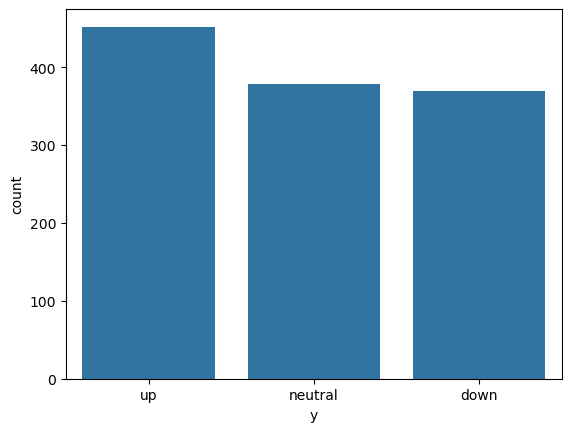

In [6]:
target_col = 'target'
if not df_train.empty:
    if 'target' not in df_train.columns:
        target_col = df_train.columns[1]
    print(f'Target: {target_col}')
    sns.countplot(x=target_col, data=df_train)
    plt.show()


# Veri Hazırlama


In [18]:
from sklearn.model_selection import train_test_split
if not df_train.empty:
    #X = df_train.drop(columns=[target_col], errors='ignore')
    #y = df_train[target_col]
    #if 'id' in X.columns: X = X.drop(columns=['id'])

    target_col = 'y'

# Eğitim verisinden atılacak sütunlar:
# - target: Hedef değişken
# - id: Ayırt edici kimlik (Feature değildir!)
# - date/Date: Tarih (Eğer gün/ay diye ayırmadıysak ham hali işe yaramaz)
    cols_to_drop = ['id', 'ID', 'Id', 'Date', 'date', target_col]

# X (Özellikler) ve y (Hedef) ayrımı
# errors='ignore' sayesinde sütun yoksa hata vermez
    X = df_train.drop(columns=cols_to_drop, errors='ignore')
    y = df_train[target_col]

    print(f"\nModelin eğitileceği özellikler ({len(X.columns)} adet):")
    print(list(X.columns))
    
    # Time Series Split (Shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)
    print(f'Train: {X_train.shape}, Val: {X_val.shape}')



Modelin eğitileceği özellikler (36 adet):
['SMA', 'EMA', 'ADX', 'Aroon', 'TDI-1', 'TDI-2', 'Donchian-1', 'Donchian-2', 'Donchian-3', 'VHF', 'CCI', 'MFI', 'OBV', 'MACD-1', 'MACD-2', 'RSI', 'Stochastics-1', 'Stochastics-2', 'Stochastics-3', 'CMO', 'KST-1', 'KST-2', 'TRIX-1', 'TRIX-2', 'ROC', 'DVI-1', 'DVI-2', 'DVI-3', 'Momentum', 'Bbands-1', 'Bbands-2', 'Bbands-3', 'Volatility', 'Pbands-1', 'Pbands-2', 'Pbands-3']
Train: (960, 36), Val: (240, 36)


# Modelleme


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [20]:
if not df_train.empty:
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_val)
    print(f'Accuracy: {accuracy_score(y_val, preds):.4f}')


Accuracy: 0.6375


# Submission


In [22]:
import os
import pandas as pd

# Test verisinin boş olup olmadığını kontrol et
if not df_test.empty:
    # 1. Submission dosyası için ID'leri sakla (Silmeden önce!)
    # ID sütununun tam adını bulalım (id, ID, Id vb.)
    id_col_name = 'id' # Varsayılan
    for col in ['id', 'ID', 'Id']:
        if col in df_test.columns:
            id_col_name = col
            break
            
    ids = df_test[id_col_name]

    # 2. Gereksiz sütunları (Eğitimde attıklarımızla aynıları) at
    # target_col değişkeni önceki hücreden geliyor olmalı, gelmiyorsa string olarak yazın
    cols_to_drop = ['id', 'ID', 'Id', 'Date', 'date', 'target', 'Target']
    
    # X_test oluştur (Temizlenmiş veri)
    X_test = df_test.drop(columns=cols_to_drop, errors='ignore')
    
    # 3. Tahmin Yap
    final_preds = pipeline.predict(X_test)
    
    # 4. Submission DataFrame oluştur
    # Kaggle genellikle 'id' veya 'Id' ve hedef değişken adını ister
    sub = pd.DataFrame({
        id_col_name: ids,
        target_col: final_preds
    })
    
    # 5. Kaydet
    output_dir = '../outputs'
    os.makedirs(output_dir, exist_ok=True)
    submission_path = os.path.join(output_dir, 'submission.csv')
    
    sub.to_csv(submission_path, index=False)
    print(f"✅ Submission dosyası başarıyla kaydedildi: {submission_path}")
    print(sub.head())
    
else:
    print("⚠️ Test verisi boş, tahmin yapılamadı.")

✅ Submission dosyası başarıyla kaydedildi: ../outputs\submission.csv
     ID        y
0  1201  neutral
1  1202     down
2  1203       up
3  1204  neutral
4  1205     down


In [ ]:
if not df_test.empty:
    X_test = df_test.drop(columns=['id'], errors='ignore')
    final_preds = pipeline.predict(X_test)
    ids = df_test['id'] if 'id' in df_test.columns else df_test.index
    sub = pd.DataFrame({'id': ids, target_col: final_preds})
    os.makedirs('../outputs', exist_ok=True)
    sub.to_csv('../outputs/submission.csv', index=False)
    print('Submission Saved.')


In [24]:
import joblib
import os

# Hedef klasör: Bir üst dizindeki 'models' klasörü
model_dir = '../models'
model_path = os.path.join(model_dir, 'best_model.pkl')

# Klasörün varlığından emin ol (yoksa oluşturur)
os.makedirs(model_dir, exist_ok=True)

# Modeli kaydet
joblib.dump(pipeline, model_path)

print(f"✅ Model başarıyla kaydedildi: {os.path.abspath(model_path)}")

✅ Model başarıyla kaydedildi: C:\Users\Erhan\Documents\0.YapayZekaKursu\Projects\PBL Level2\Hw.15.BecomeAPro\9.Classification_TeslaStock\models\best_model.pkl
